# 03 · ResNet-50 baseline (Baseline 2, Ablation A)

**Goal:** a larger CNN trained exactly like ResNet-18, to see what the extra capacity gives.

The training code lives in `src/common.py` so every model is trained and scored the same way.

## 1. Project folder

In [2]:
# Run this cell first, every time you open the notebook.
import os, sys
from pathlib import Path

if "google.colab" in sys.modules:                       # Google Colab
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/MalariaScanAI")  # where you unzipped the project
else:                                                   # your own laptop
    ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print("Project folder:", ROOT)

Project folder: c:\Users\VOTHY VYSAL\Documents\MalariaScanAI


## 2. Environment, GPU and dataset

In [3]:
from src.common import *

set_seed(42)
print_environment()

Python : 3.13.14
PyTorch: 2.14.1+cu126
CUDA available: True
Device: cuda
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
GPU memory: 4.0 GB
train images: 19363
val images: 4323
test images: 3872
Number of classes: 2
Classes: ['PARASITIZED', 'UNINFECTED']


## 3. Train

ImageNet weights, new classification head, all layers trained with AdamW (learning rate 1e-4), no augmentation, no scheduler. The parameter counts are calculated from the real model and printed first. The best checkpoint (highest validation Macro-F1) is saved, and training stops early if validation stops improving.

Out of GPU memory? Change `batch_size` to 8. Short on time? Lower `epochs`.

In [4]:
info = train("resnet50", epochs=15, patience=3, batch_size=16)

resnet50
Total parameters:         23,512,130
Trainable parameters:     23,512,130
Non-trainable parameters: 0

Epoch 1/15
Train Loss: 0.135
Train Accuracy: 95.36%
Val Loss: 0.176
Val Accuracy: 94.29%
Val Macro-F1: 94.07%
Time: 189.0 sec

Epoch 2/15
Train Loss: 0.088
Train Accuracy: 96.98%
Val Loss: 0.131
Val Accuracy: 95.47%
Val Macro-F1: 95.27%
Time: 200.8 sec

Epoch 3/15
Train Loss: 0.070
Train Accuracy: 97.49%
Val Loss: 0.136
Val Accuracy: 95.33%
Val Macro-F1: 95.12%
Time: 196.4 sec

Epoch 4/15
Train Loss: 0.050
Train Accuracy: 98.34%
Val Loss: 0.134
Val Accuracy: 95.70%
Val Macro-F1: 95.49%
Time: 197.1 sec

Epoch 5/15
Train Loss: 0.041
Train Accuracy: 98.53%
Val Loss: 0.148
Val Accuracy: 95.56%
Val Macro-F1: 95.35%
Time: 199.8 sec

Epoch 6/15
Train Loss: 0.035
Train Accuracy: 98.79%
Val Loss: 0.154
Val Accuracy: 95.56%
Val Macro-F1: 95.34%
Time: 189.4 sec

Epoch 7/15
Train Loss: 0.027
Train Accuracy: 99.08%
Val Loss: 0.190
Val Accuracy: 94.96%
Val Macro-F1: 94.74%
Time: 188.3 sec


## 4. Training curves

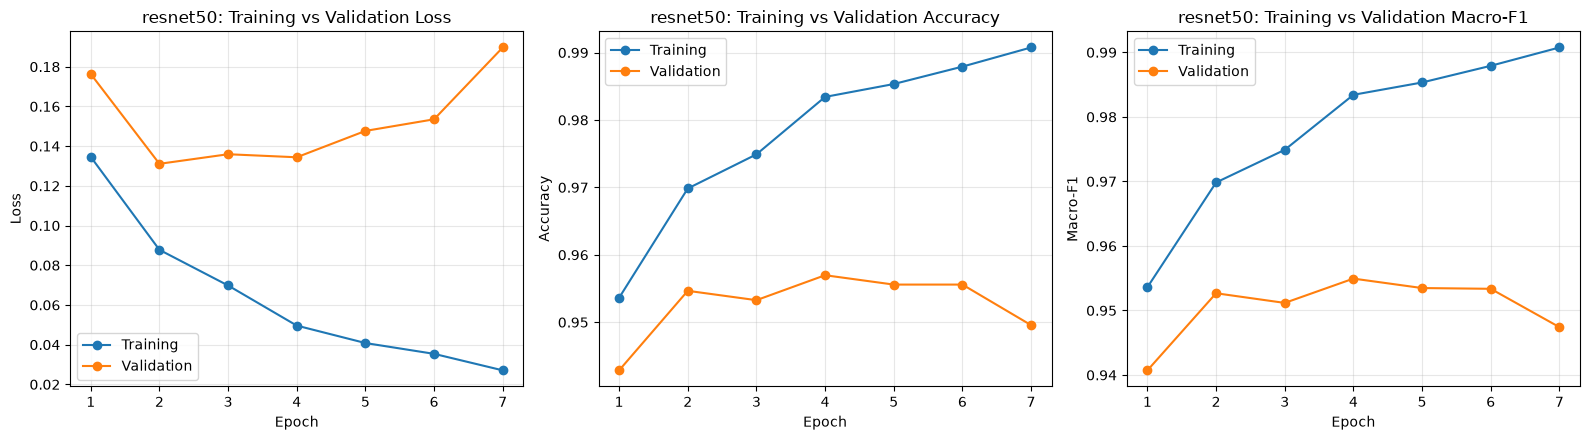

In [5]:
plot_history("resnet50")

## 5. Test results

In [ ]:
metrics, cm, classes, report = evaluate("resnet50")
for k in ("accuracy", "precision", "recall", "macro_f1"):
    print(f"Test {k}: {metrics[k] * 100:.2f}%")
print()
print(report)

Test accuracy: 97.44%
Test precision: 97.30%
Test recall: 97.28%
Test macro_f1: 97.29%

              precision    recall  f1-score   support

 PARASITIZED       0.97      0.97      0.97      1477
  UNINFECTED       0.98      0.98      0.98      2395

    accuracy                           0.97      3872
   macro avg       0.97      0.97      0.97      3872
weighted avg       0.97      0.97      0.97      3872



: 